In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

hc3 = pd.read_csv('hc3_clean.csv')
isot = pd.read_csv('isot_clean.csv')

# Build one unified dataframe with a consistent text column and a group label
ai     = hc3[hc3['label'] == 'ai'][['text']].copy();          ai['group'] = 'AI'
human  = hc3[hc3['label'] == 'human'][['text']].copy();       human['group'] = 'Human'
fake   = isot[isot['label'] == 'fake'][['text_clean']].rename(columns={'text_clean':'text'}); fake['group'] = 'Fake'
real   = isot[isot['label'] == 'real'][['text_clean']].rename(columns={'text_clean':'text'}); real['group'] = 'Real'

df = pd.concat([ai, human, fake, real], ignore_index=True)
df['text'] = df['text'].astype(str)
df = df[df['text'].str.split().str.len() >= 20].reset_index(drop=True)  # drop near-empty rows
print(df['group'].value_counts())

group
Real     20819
Fake     17087
AI        4752
Human     4675
Name: count, dtype: int64


In [3]:
WINDOW = 120  # words; ~ the length of a short news article or a HC3 answer

def truncate(text, n=WINDOW):
    return ' '.join(str(text).split()[:n])

df['text_trunc'] = df['text'].apply(truncate)

In [4]:
FUNCTION_WORDS = ['the','a','an','and','but','or','if','of','to','in','on','for',
                  'with','as','that','this','it','is','are','was','were','be']
HEDGES   = ['may','might','could','perhaps','possibly','likely','generally',
            'often','typically','usually','can','suggests','overall']
def features(text):
    words = re.findall(r"[a-zA-Z']+", text.lower())
    sentences = [s for s in re.split(r'[.!?]+', text) if s.strip()]
    n_words = max(len(words), 1)
    n_sents = max(len(sentences), 1)
    word_lens = [len(w) for w in words]
    sent_lens = [len(s.split()) for s in sentences]

    return {
        'avg_word_len':     np.mean(word_lens) if word_lens else 0,
        'avg_sent_len':     np.mean(sent_lens) if sent_lens else 0,
        'sent_len_std':     np.std(sent_lens) if len(sent_lens) > 1 else 0,  # burstiness
        'ttr':              len(set(words)) / n_words,                       # lexical diversity
        'comma_rate':       text.count(',') / n_words,
        'punct_rate':       len(re.findall(r'[;:\-\(\)"]', text)) / n_words,
        'digit_rate':       len(re.findall(r'\d', text)) / max(len(text),1),
        'uppercase_rate':   sum(c.isupper() for c in text) / max(len(text),1),
        'function_word_rate': sum(w in FUNCTION_WORDS for w in words) / n_words,
        'hedge_rate':       sum(w in HEDGES for w in words) / n_words,
        'quote_rate':       (text.count('"') + text.count('“')) / n_sents,
        'long_word_rate':   sum(l >= 7 for l in word_lens) / n_words,
    }

feat_df = df['text_trunc'].apply(features).apply(pd.Series)
df = pd.concat([df, feat_df], axis=1)
FEATURES = list(feat_df.columns)

group                    AI     Fake    Human     Real
avg_word_len         4.7890   4.6993   4.6427   4.9634
avg_sent_len        22.1462  20.5469  18.6122  19.7801
sent_len_std         8.0731  10.9252   8.6460  11.2955
ttr                  0.5681   0.7126   0.6887   0.7089
comma_rate           0.0470   0.0443   0.0462   0.0456
punct_rate           0.0284   0.0199   0.0421   0.0206
digit_rate           0.0028   0.0053   0.0085   0.0055
uppercase_rate       0.0172   0.0437   0.0227   0.0386
function_word_rate   0.3348   0.2633   0.2966   0.2654
hedge_rate           0.0231   0.0043   0.0128   0.0038
quote_rate           0.0796   0.0037   0.1320   0.0912
long_word_rate       0.2600   0.2325   0.2239   0.2825


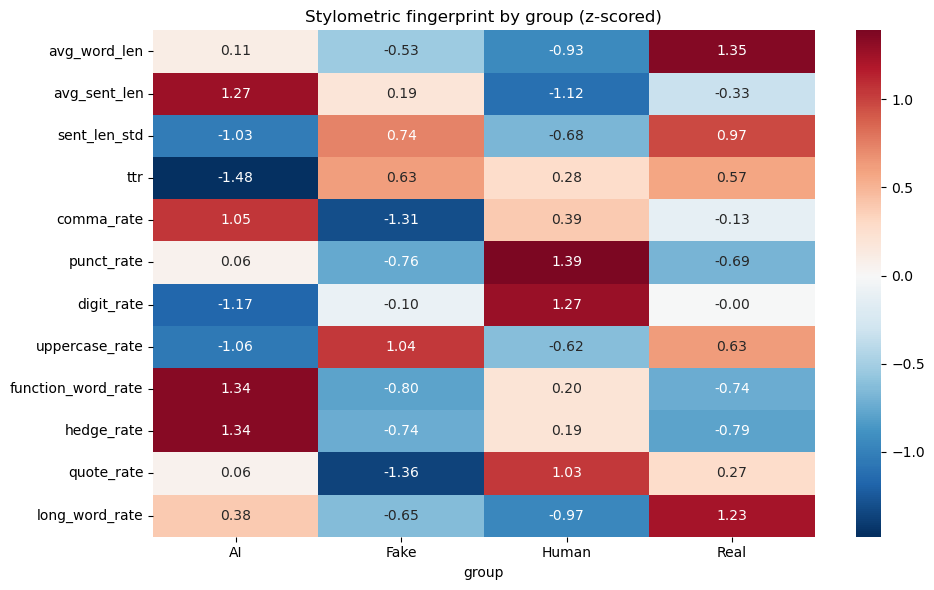

In [5]:
profile = df.groupby('group')[FEATURES].mean()
print(profile.T.round(4))

# Heatmap of z-scored feature means — instantly shows which groups look alike
z = (profile - profile.mean()) / profile.std()
plt.figure(figsize=(10,6))
sns.heatmap(z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Stylometric fingerprint by group (z-scored)')
plt.tight_layout(); plt.savefig('fingerprint_heatmap.png', dpi=150)

In [6]:
from scipy.spatial.distance import euclidean, cosine

# z-score features across the whole dataset so each weighs equally
z_all = df.copy()
z_all[FEATURES] = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()
centroids = z_all.groupby('group')[FEATURES].mean()

ai_vec = centroids.loc['AI']
for g in ['Fake','Real','Human']:
    print(f'AI vs {g:6s} | Euclidean: {euclidean(ai_vec, centroids.loc[g]):.3f}'
          f' | Cosine: {cosine(ai_vec, centroids.loc[g]):.4f}')

AI vs Fake   | Euclidean: 3.320 | Cosine: 1.6158
AI vs Real   | Euclidean: 3.246 | Cosine: 1.5703
AI vs Human  | Euclidean: 2.353 | Cosine: 0.4698


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

news = df[df['group'].isin(['Fake','Real'])]
X = StandardScaler().fit_transform(news[FEATURES])
y = (news['group'] == 'Fake').astype(int)

clf = LogisticRegression(max_iter=1000)
print('CV accuracy (fake vs real on style alone):', cross_val_score(clf, X, y, cv=5).mean().round(3))

clf.fit(X, y)
scaler = StandardScaler().fit(news[FEATURES])
ai_X = scaler.transform(df[df['group']=='AI'][FEATURES])
ai_pred = clf.predict(ai_X)
print(f'AI texts classified as FAKE-news style: {ai_pred.mean()*100:.1f}%')

# which features push that decision
coefs = pd.Series(clf.coef_[0], index=FEATURES).sort_values()
print(coefs)

CV accuracy (fake vs real on style alone): 0.734
AI texts classified as FAKE-news style: 24.1%
quote_rate           -2.023863
long_word_rate       -0.747267
avg_word_len         -0.428342
function_word_rate   -0.238758
punct_rate           -0.147548
digit_rate           -0.061931
hedge_rate           -0.020506
comma_rate            0.013137
sent_len_std          0.060670
ttr                   0.095974
avg_sent_len          0.132086
uppercase_rate        0.393436
dtype: float64


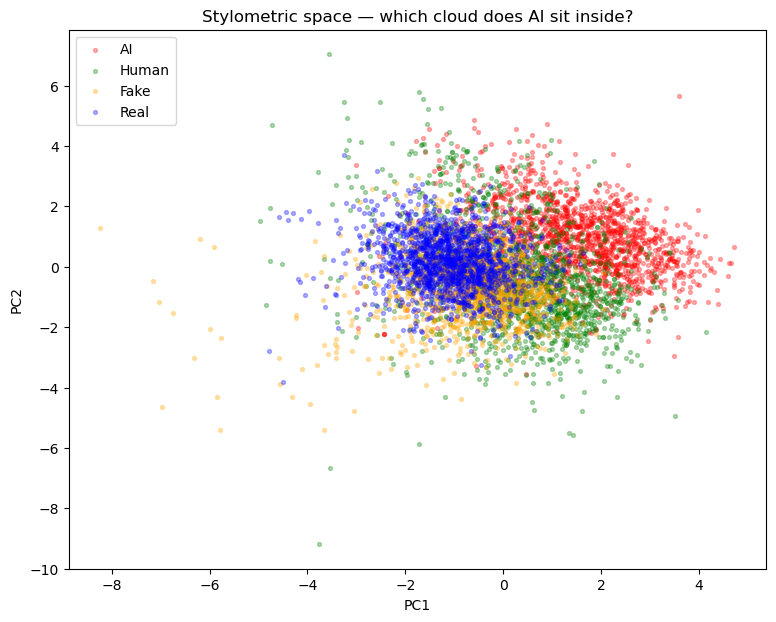

In [8]:
from sklearn.decomposition import PCA

samp = df.groupby('group').sample(n=1500, random_state=1, replace=False)
coords = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(samp[FEATURES]))
samp = samp.assign(PC1=coords[:,0], PC2=coords[:,1])

plt.figure(figsize=(9,7))
for g,c in zip(['AI','Human','Fake','Real'], ['red','green','orange','blue']):
    s = samp[samp['group']==g]
    plt.scatter(s['PC1'], s['PC2'], s=8, alpha=0.3, label=g, color=c)
plt.legend(); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Stylometric space — which cloud does AI sit inside?')
plt.savefig('pca_space.png', dpi=150)

In [9]:
from scipy.stats import ttest_ind
for feat in FEATURES:
    a = df[df['group']=='AI'][feat]
    f = ttest_ind(a, df[df['group']=='Fake'][feat], equal_var=False).pvalue
    r = ttest_ind(a, df[df['group']=='Real'][feat], equal_var=False).pvalue
    print(f'{feat:20s} p(AI≠Fake)={f:.2e}  p(AI≠Real)={r:.2e}')

avg_word_len         p(AI≠Fake)=6.76e-42  p(AI≠Real)=5.88e-155
avg_sent_len         p(AI≠Fake)=8.72e-64  p(AI≠Real)=6.38e-146
sent_len_std         p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
ttr                  p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
comma_rate           p(AI≠Fake)=9.05e-12  p(AI≠Real)=3.60e-04
punct_rate           p(AI≠Fake)=3.50e-74  p(AI≠Real)=3.43e-65
digit_rate           p(AI≠Fake)=3.28e-76  p(AI≠Real)=7.99e-100
uppercase_rate       p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
function_word_rate   p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
hedge_rate           p(AI≠Fake)=0.00e+00  p(AI≠Real)=0.00e+00
quote_rate           p(AI≠Fake)=3.40e-81  p(AI≠Real)=4.42e-03
long_word_rate       p(AI≠Fake)=6.20e-124  p(AI≠Real)=2.30e-87


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 15,
                     'axes.titleweight': 'bold', 'figure.dpi': 150})
PALETTE = {'AI':'#E63946', 'Human':'#2A9D8F', 'Fake':'#F4A261', 'Real':'#264653'}
ORDER = ['AI', 'Human', 'Fake', 'Real']

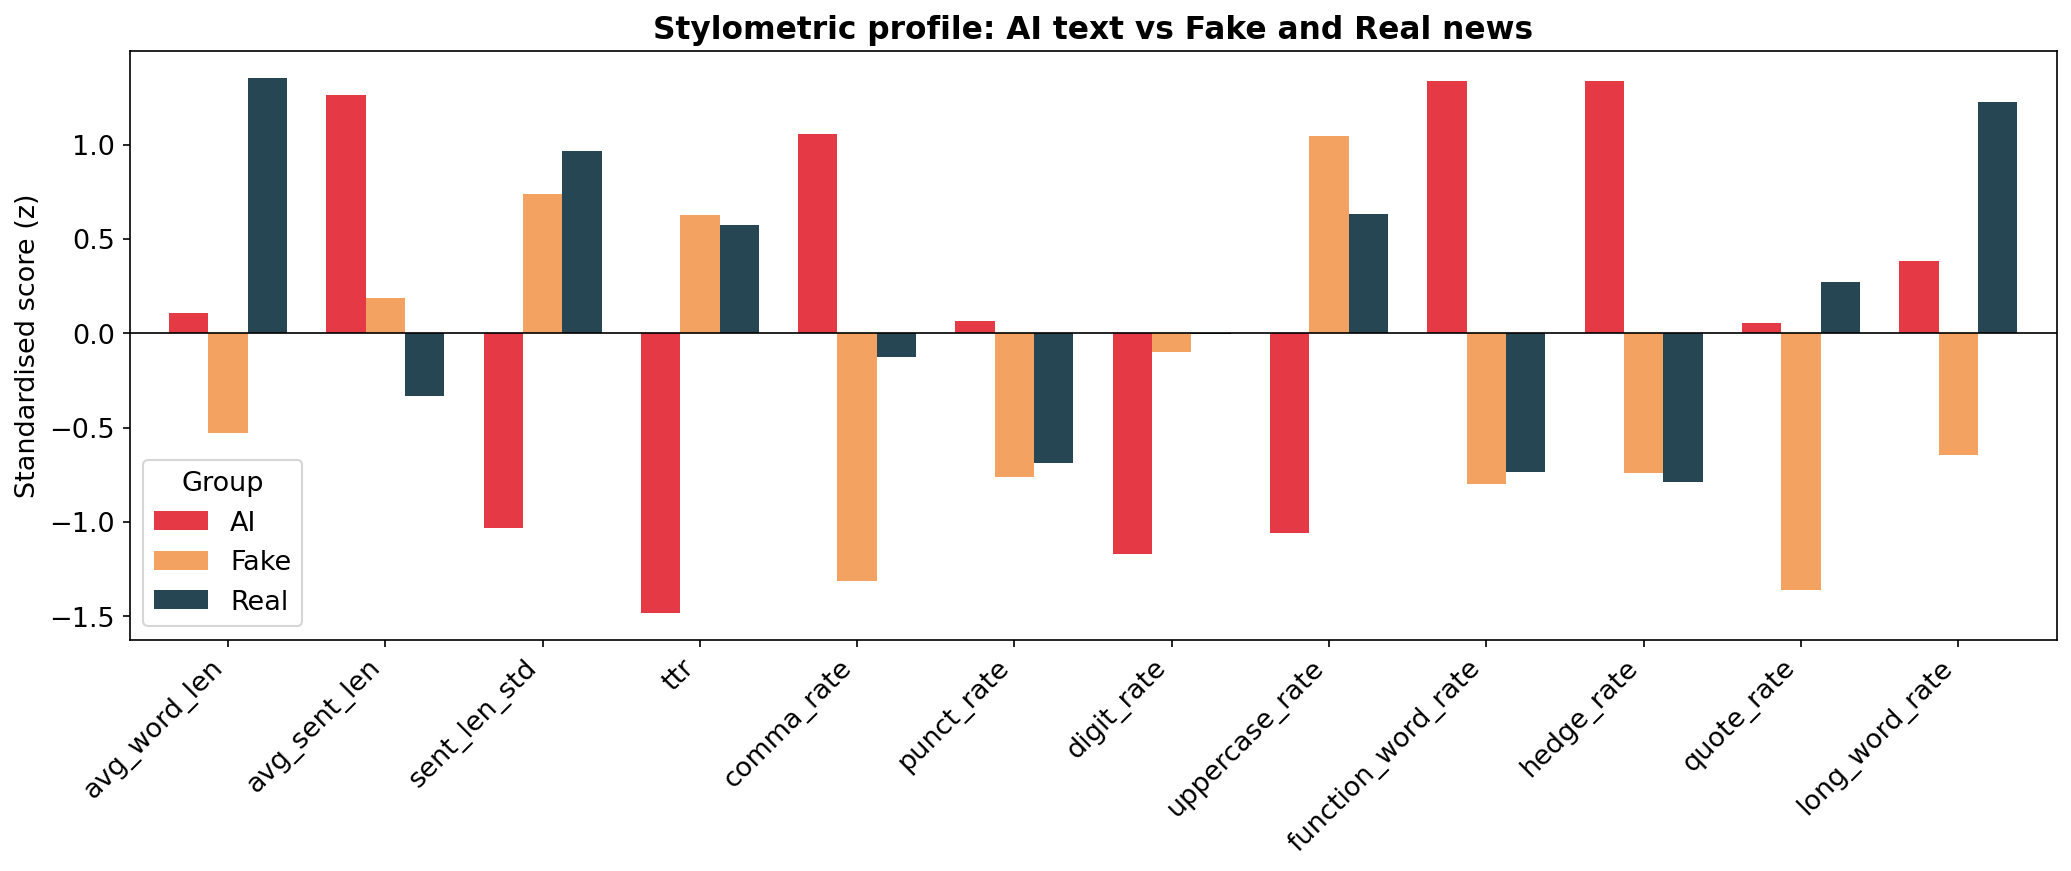

In [20]:
news_groups = ['AI', 'Fake', 'Real']
z_news = ((profile - profile.mean()) / profile.std()).loc[news_groups]
ax = z_news.T.plot(kind='bar', figsize=(14,6),
                   color=[PALETTE[g] for g in news_groups], width=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Standardised score (z)')
ax.set_title('Stylometric profile: AI text vs Fake and Real news')
ax.legend(title='Group'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('chart_bar_features.png', bbox_inches='tight'); plt.show()

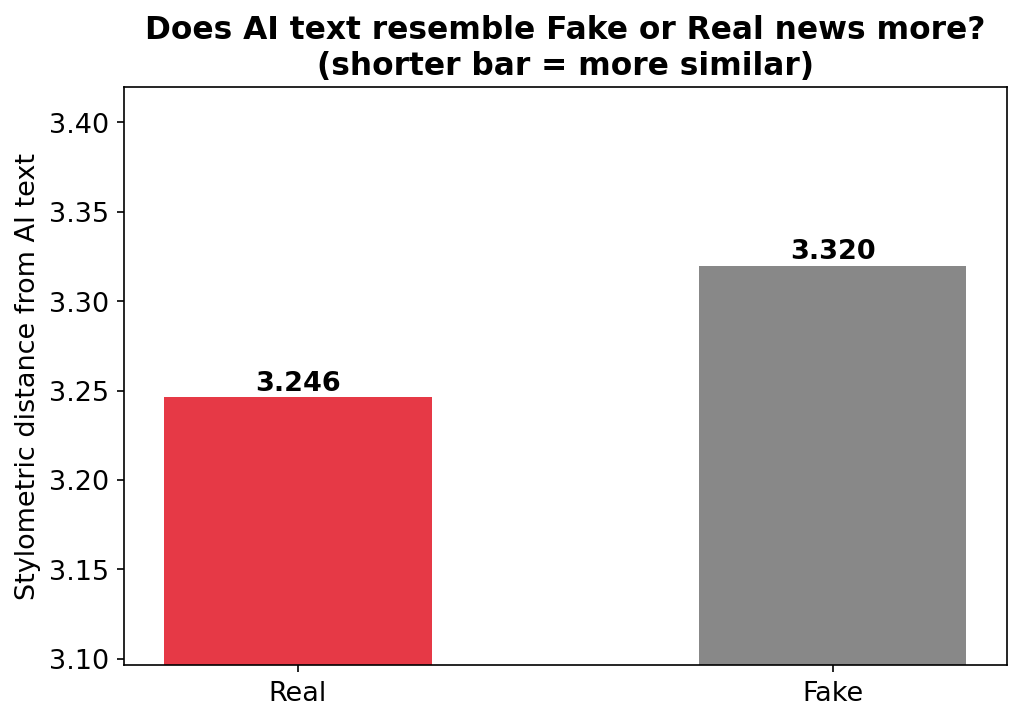

In [14]:
news_only = ['Fake', 'Real']
nd = pd.Series({g: dists[g] for g in news_only}).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#E63946' if g == nd.idxmin() else '#888888' for g in nd.index]
bars = ax.bar(nd.index, nd.values, color=colors, width=0.5)
ax.set_ylabel('Stylometric distance from AI text')
ax.set_title('Does AI text resemble Fake or Real news more?\n(shorter bar = more similar)')
for b, v in zip(bars, nd.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', fontweight='bold')
# zoom the axis to the data range so the gap is visible
ax.set_ylim(min(nd.values)-0.15, max(nd.values)+0.10)
plt.tight_layout(); plt.savefig('chart_distance_newszoom.png', bbox_inches='tight'); plt.show()

/var/folders/45/5n_0_w0x61s50f7w1md96r_00000gn/T/ipykernel_1700/1595157422.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='group', y=feat, order=news_groups,
/var/folders/45/5n_0_w0x61s50f7w1md96r_00000gn/T/ipykernel_1700/1595157422.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='group', y=feat, order=news_groups,
/var/folders/45/5n_0_w0x61s50f7w1md96r_00000gn/T/ipykernel_1700/1595157422.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x='group', y=feat, order=news_groups,
/var/folders/

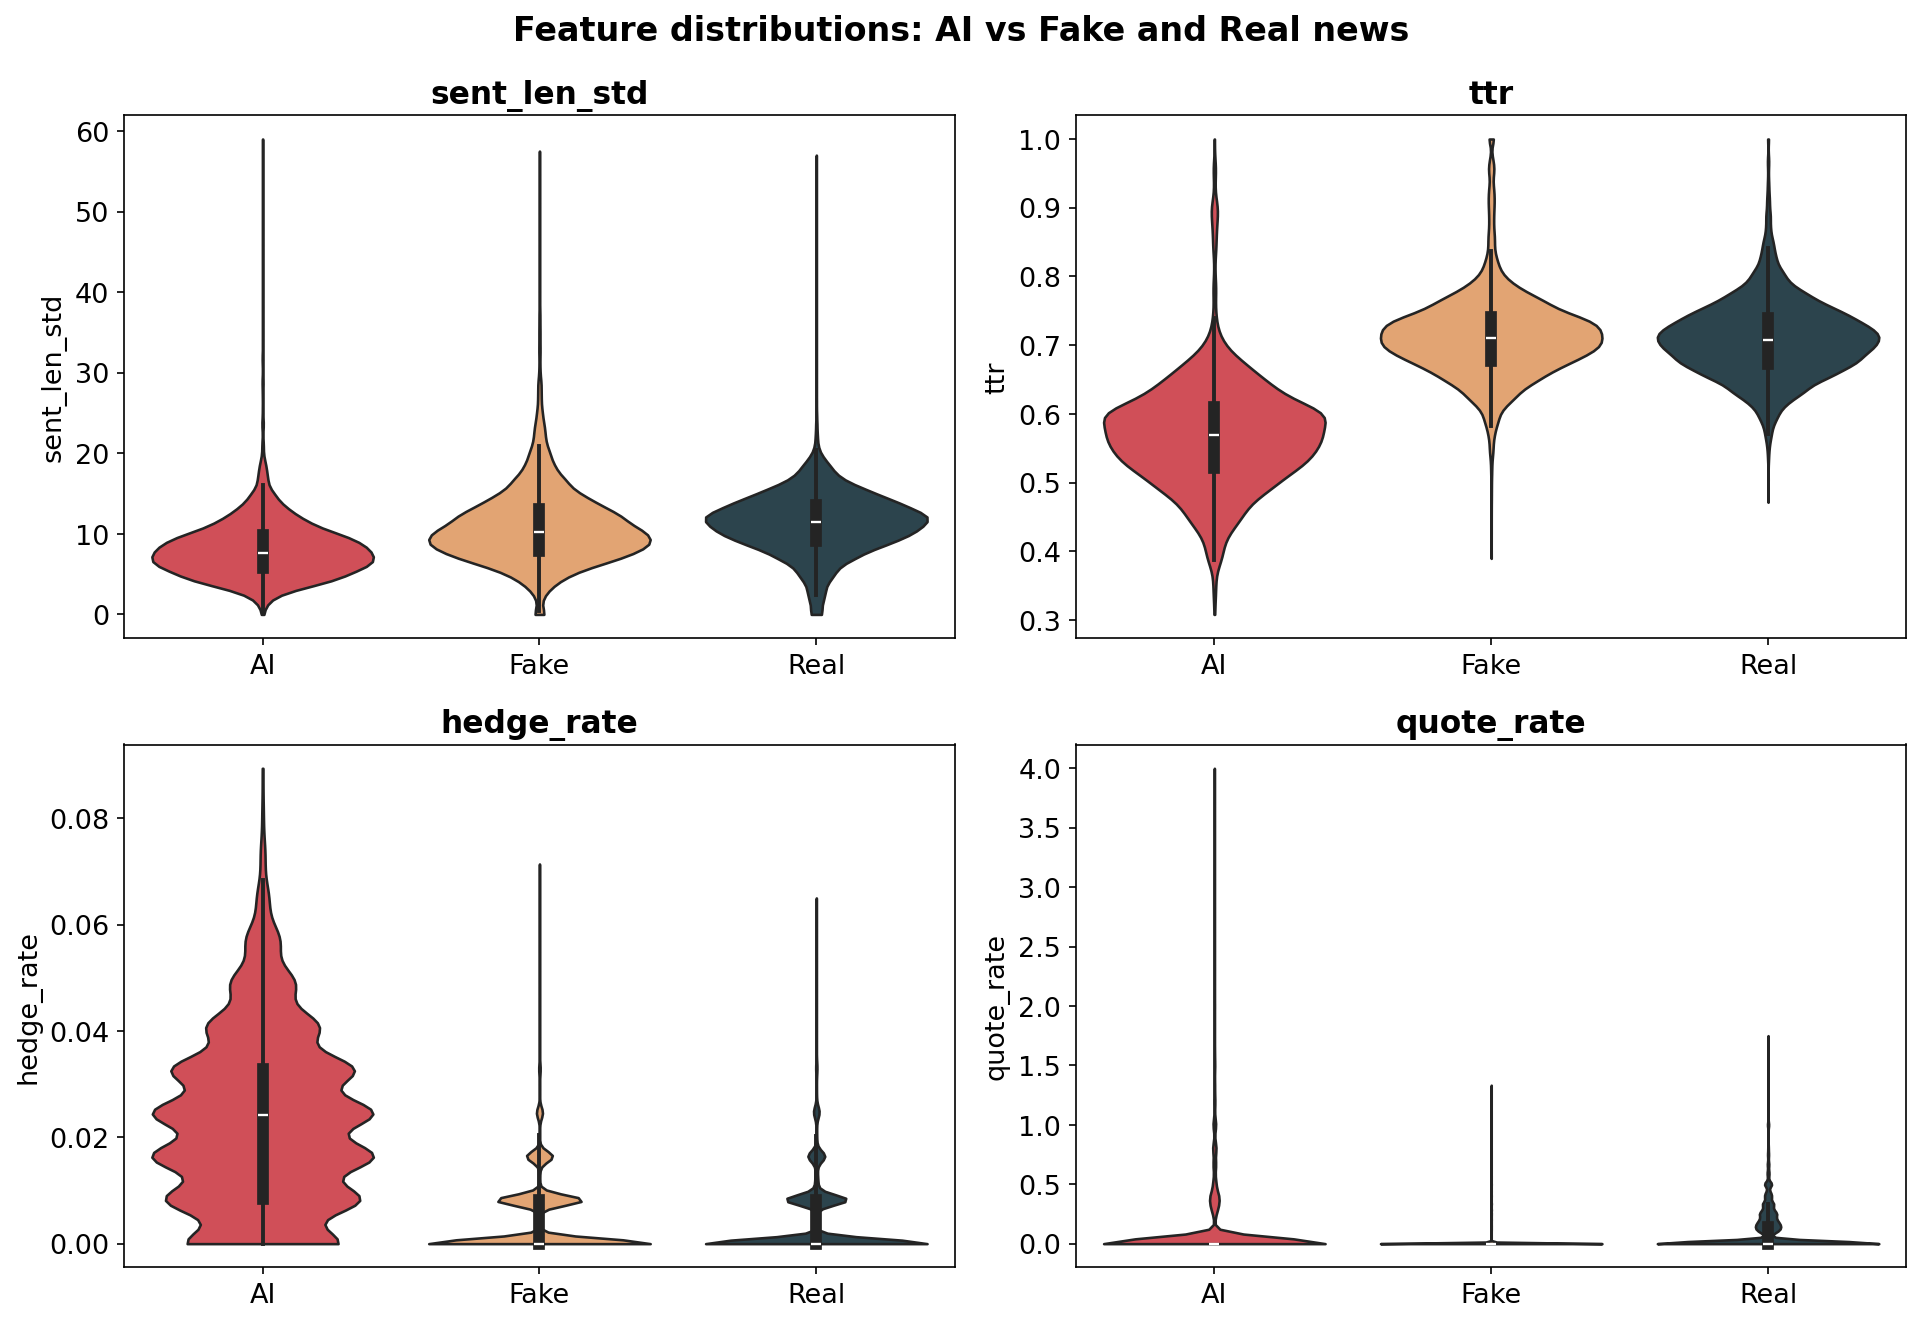

In [15]:
import seaborn as sns

news_groups = ['AI', 'Fake', 'Real']
sub = df[df['group'].isin(news_groups)]
key_feats = ['sent_len_std', 'ttr', 'hedge_rate', 'quote_rate']

fig, axes = plt.subplots(2, 2, figsize=(13,9))
for ax, feat in zip(axes.flat, key_feats):
    sns.violinplot(data=sub, x='group', y=feat, order=news_groups,
                   palette=PALETTE, ax=ax, cut=0)
    ax.set_title(feat); ax.set_xlabel('')
fig.suptitle('Feature distributions: AI vs Fake and Real news',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('chart_violin_newsonly.png', bbox_inches='tight'); plt.show()

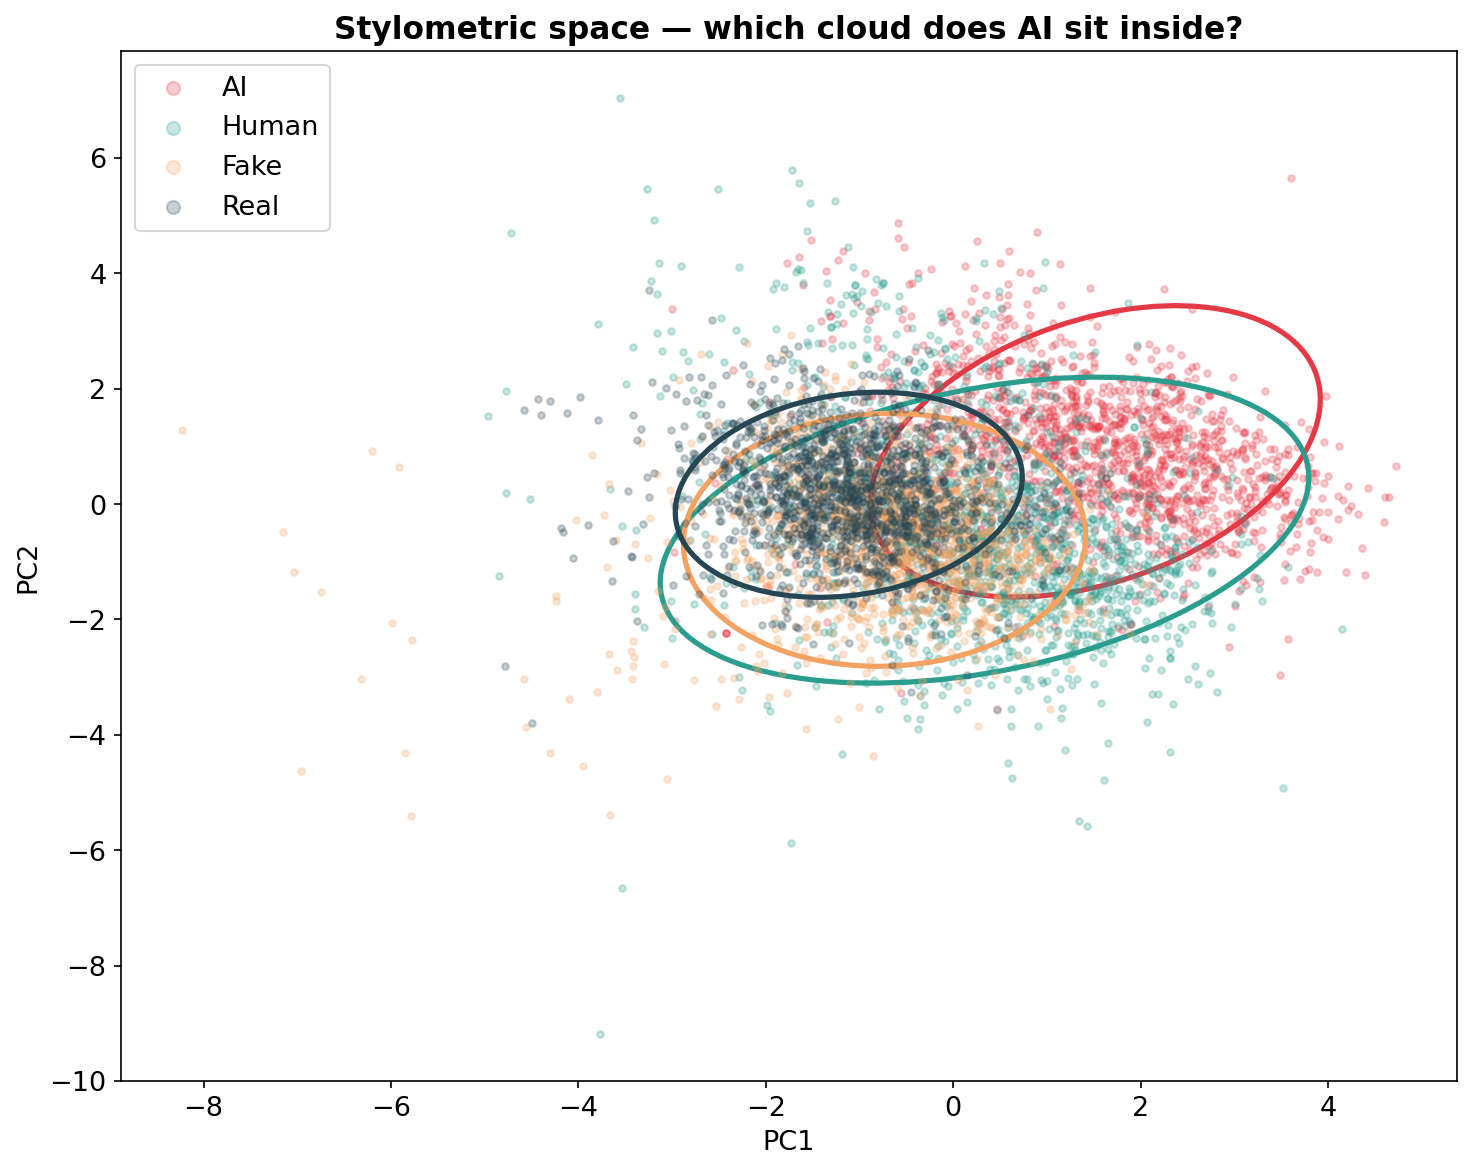

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

samp = df.groupby('group').sample(n=1500, random_state=1)
coords = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(samp[FEATURES]))
samp = samp.assign(PC1=coords[:,0], PC2=coords[:,1])

fig, ax = plt.subplots(figsize=(10,8))
for g in ORDER:
    s = samp[samp['group']==g]
    ax.scatter(s['PC1'], s['PC2'], s=10, alpha=0.25, color=PALETTE[g], label=g)
    mx, my = s['PC1'].mean(), s['PC2'].mean()
    cov = np.cov(s['PC1'], s['PC2'])
    vals, vecs = np.linalg.eigh(cov)
    ang = np.degrees(np.arctan2(*vecs[:,1][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)  # ~2 std-dev ellipse
    ax.add_patch(Ellipse((mx,my), w, h, angle=ang, fill=False,
                         edgecolor=PALETTE[g], linewidth=2.5))
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Stylometric space — which cloud does AI sit inside?')
ax.legend(markerscale=2)
plt.tight_layout(); plt.savefig('pca_ellipses.png', bbox_inches='tight')
plt.show()

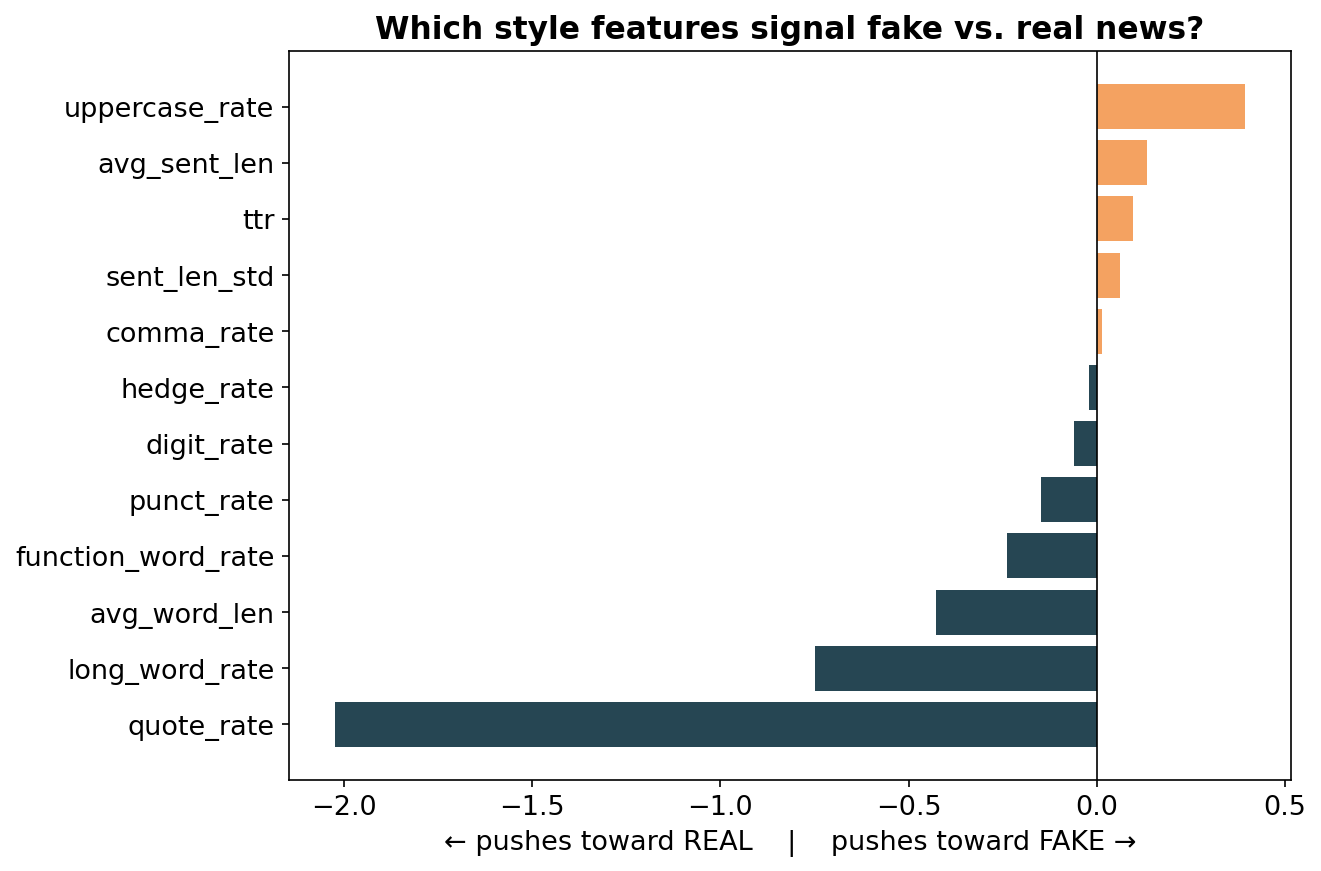

In [17]:
coefs = pd.Series(clf.coef_[0], index=FEATURES).sort_values()
colors = ['#264653' if c < 0 else '#F4A261' for c in coefs.values]  # blue=Real-leaning, orange=Fake-leaning

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(coefs.index, coefs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('← pushes toward REAL    |    pushes toward FAKE →')
ax.set_title('Which style features signal fake vs. real news?')
plt.tight_layout(); plt.savefig('classifier_coefs.png', bbox_inches='tight')
plt.show()

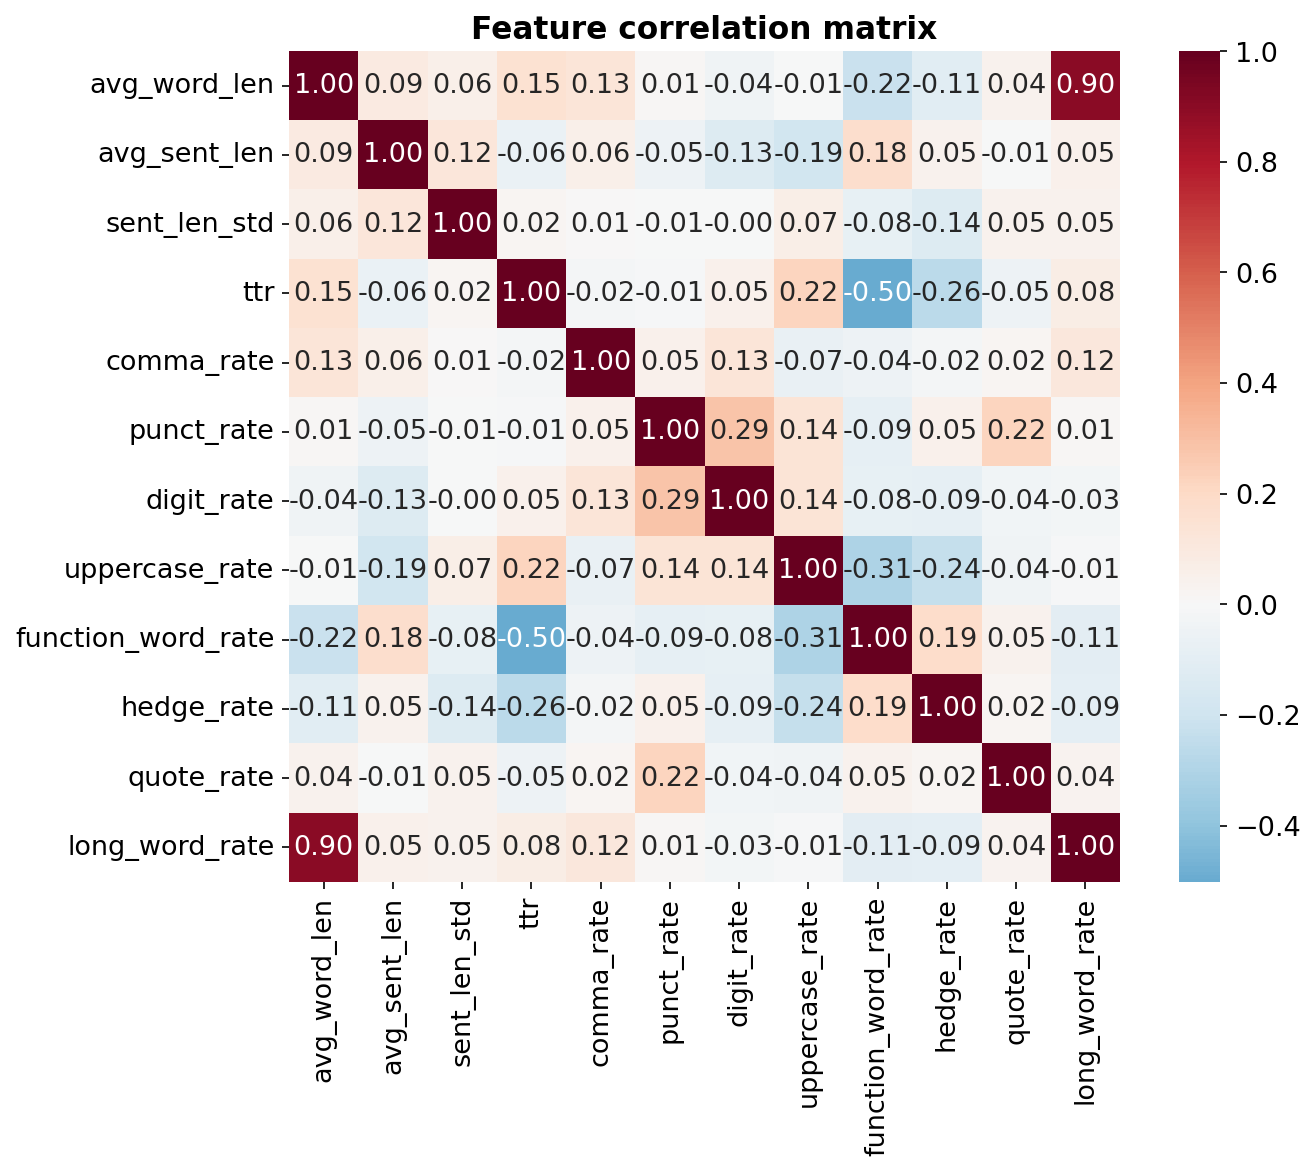

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True)
plt.title('Feature correlation matrix')
plt.tight_layout(); plt.savefig('feature_correlations.png', bbox_inches='tight')
plt.show()

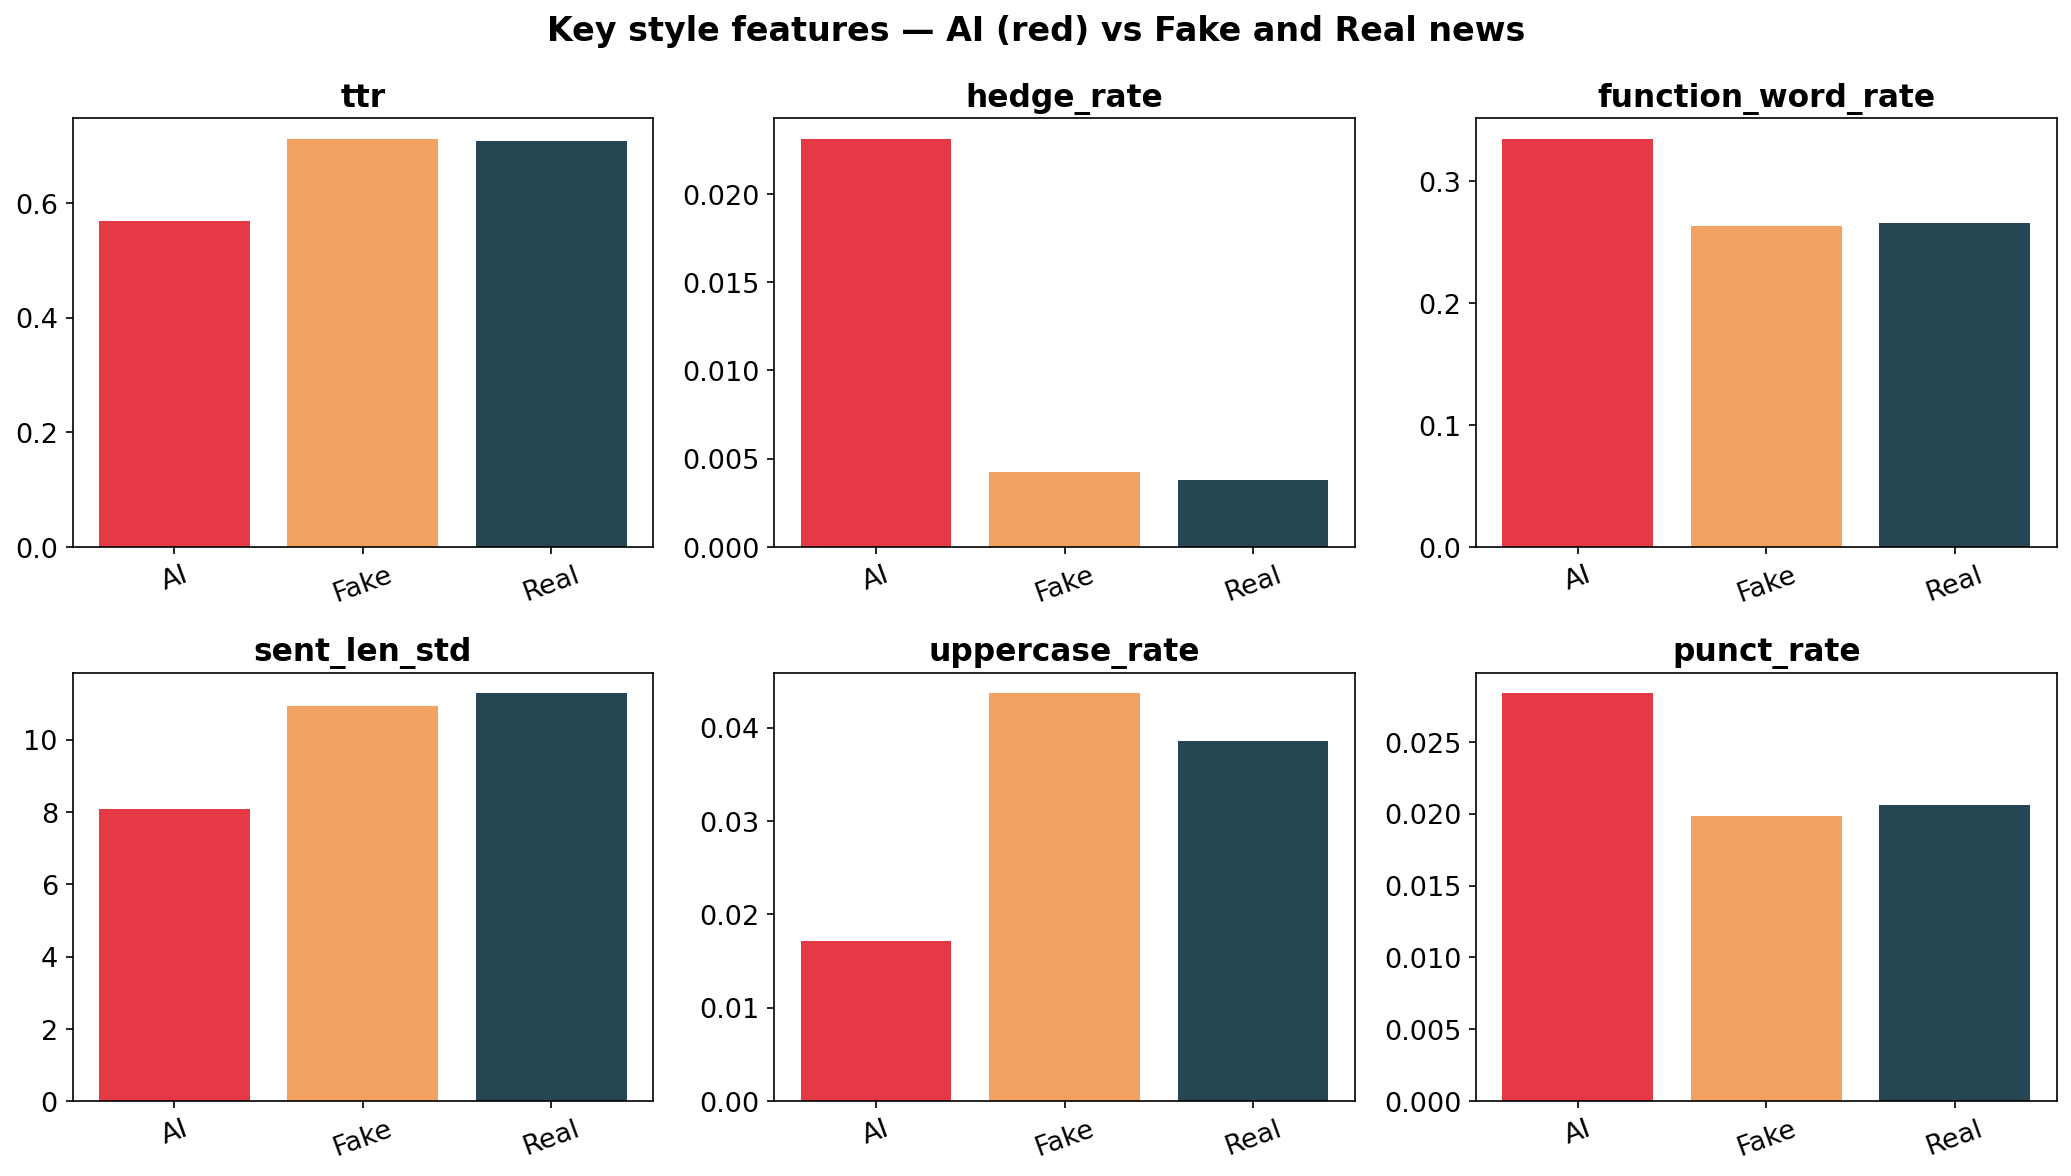

In [21]:
news_groups = ['AI', 'Fake', 'Real']
key = ['ttr','hedge_rate','function_word_rate','sent_len_std','uppercase_rate','punct_rate']
fig, axes = plt.subplots(2,3, figsize=(14,8))
for ax, f in zip(axes.flat, key):
    ax.bar(news_groups, profile.loc[news_groups, f],
           color=[PALETTE[g] for g in news_groups])
    ax.set_title(f); ax.tick_params(axis='x', rotation=20)
fig.suptitle('Key style features — AI (red) vs Fake and Real news',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('chart_key_features.png', bbox_inches='tight'); plt.show()